# Notebook 04: SHAP Explanations and Intervention Planning

## Objective 2

Implement an explanation and intervention planning module that:

1. Uses SHAP to identify global and student level risk factors.
2. Explains which features increase an individual student's predicted risk.
3. Links important risk factors to suitable support actions.
4. Produces an anonymised intervention plan for high risk test cases.

The intervention recommendations are decision support suggestions. They do not prove that a feature caused the predicted outcome, and final decisions should remain with qualified academic staff.


## 1. Install SHAP only if required


In [4]:
# Run this cell only if SHAP is not installed:
# %pip install shap


## 2. Import libraries


In [5]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "SHAP is not installed. Run `%pip install shap`, "
        "restart the kernel, and rerun the notebook."
    ) from error

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

RANDOM_STATE = 42

print("Libraries imported successfully.")
print("SHAP version:", shap.__version__)


Libraries imported successfully.
SHAP version: 0.51.0


## 3. Load the model and prepared data


In [6]:
CURRENT_DIR = Path.cwd()

PROJECT_DIR = (
    CURRENT_DIR.parent
    if CURRENT_DIR.name == "notebooks"
    else CURRENT_DIR
)

DATA_DIR = (
    PROJECT_DIR
    / "data"
    / "processed"
)

MODEL_DIR = (
    PROJECT_DIR
    / "results"
    / "baseline_models"
)

OUTPUT_DIR = (
    PROJECT_DIR
    / "results"
    / "explainability_interventions"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

X_train_prepared = pd.read_pickle(
    DATA_DIR / "X_train_prepared.pkl"
)

X_test_prepared = pd.read_pickle(
    DATA_DIR / "X_test_prepared.pkl"
)

X_test_raw = pd.read_pickle(
    DATA_DIR / "X_test_raw.pkl"
)

y_test = pd.read_pickle(
    DATA_DIR / "y_test.pkl"
)

MODEL_FILE = (
    MODEL_DIR
    / "best_baseline_model.joblib"
)

if not MODEL_FILE.exists():
    MODEL_FILE = (
        MODEL_DIR
        / "random_forest.joblib"
    )

if not MODEL_FILE.exists():
    raise FileNotFoundError(
        "The saved baseline model was not found."
    )

model = joblib.load(
    MODEL_FILE
)

best_model_name_file = (
    MODEL_DIR
    / "best_model_name.txt"
)

if best_model_name_file.exists():
    best_model_name = (
        best_model_name_file
        .read_text(encoding="utf-8")
        .strip()
    )
else:
    best_model_name = type(model).__name__

print("Loaded model:", best_model_name)
print("Prepared training shape:", X_train_prepared.shape)
print("Prepared testing shape:", X_test_prepared.shape)
print("Raw testing shape:", X_test_raw.shape)


Loaded model: Random Forest
Prepared training shape: (3008, 35)
Prepared testing shape: (752, 35)
Raw testing shape: (752, 23)


## 4. Calculate predicted risk probabilities


In [7]:
test_probabilities = model.predict_proba(
    X_test_prepared
)[:, 1]

test_predictions = (
    test_probabilities >= 0.50
).astype(int)

prediction_summary = pd.DataFrame({
    "actual_label": y_test.to_numpy(),
    "predicted_label": test_predictions,
    "predicted_risk_probability": test_probabilities,
}, index=X_test_prepared.index)

display(
    prediction_summary
    .sort_values(
        "predicted_risk_probability",
        ascending=False,
    )
    .head(10)
)

print(
    "Students predicted at risk:",
    int(test_predictions.sum()),
)


,actual_label,predicted_label,predicted_risk_probability
1080,1,1,1.000000
1029,1,1,0.996667
147,1,1,0.990000
2496,1,1,0.983333
430,1,1,0.983333
1037,1,1,0.976710
1024,1,1,0.973363
2491,1,1,0.966667
3403,1,1,0.960000
3054,1,1,0.953333


Students predicted at risk: 211


## 5. Create the SHAP explainer

Random Forest is a tree based model, so TreeExplainer is used. SHAP values greater than zero indicate that a feature pushed the prediction towards the at risk class. Values below zero pushed it towards the not at risk class.


In [8]:
explainer = shap.TreeExplainer(
    model
)

raw_shap_values = explainer.shap_values(
    X_test_prepared
)


def extract_positive_class_shap(
    shap_values,
    row_count,
    feature_count,
):
    if isinstance(shap_values, list):
        if len(shap_values) < 2:
            return np.asarray(
                shap_values[0]
            )
        return np.asarray(
            shap_values[1]
        )

    values = np.asarray(
        shap_values
    )

    if values.ndim == 2:
        return values

    if values.ndim == 3:

        # Shape:
        # rows, features, classes
        if (
            values.shape[0] == row_count
            and values.shape[1] == feature_count
        ):
            return values[:, :, 1]

        # Shape:
        # classes, rows, features
        if (
            values.shape[1] == row_count
            and values.shape[2] == feature_count
        ):
            return values[1, :, :]

    raise ValueError(
        "Unexpected SHAP value shape: "
        f"{values.shape}"
    )


positive_class_shap = extract_positive_class_shap(
    raw_shap_values,
    row_count=len(X_test_prepared),
    feature_count=X_test_prepared.shape[1],
)

expected_value = np.asarray(
    explainer.expected_value
)

if expected_value.ndim == 0:
    positive_class_base_value = float(
        expected_value
    )
else:
    positive_class_base_value = float(
        expected_value.reshape(-1)[-1]
    )

print(
    "Positive class SHAP shape:",
    positive_class_shap.shape,
)

print(
    "Positive class base value:",
    positive_class_base_value,
)


Positive class SHAP shape: (752, 35)
Positive class base value: 0.5001130319148939


## 6. Global SHAP importance


In [9]:
global_shap_importance = pd.DataFrame({
    "feature": X_test_prepared.columns,
    "mean_absolute_shap": np.abs(
        positive_class_shap
    ).mean(axis=0),
})

global_shap_importance = (
    global_shap_importance
    .sort_values(
        "mean_absolute_shap",
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    global_shap_importance
    .head(20)
    .round(5)
)

global_shap_importance.to_csv(
    OUTPUT_DIR
    / "global_shap_importance.csv",
    index=False,
)


,feature,mean_absolute_shap
0,previous_cgpa_ordinal,0.06716
1,repeated_course_count_current,0.06239
2,previous_term_gpa_ordinal,0.05781
3,previous_failed_course_count,0.05295
4,year_level_4,0.04797
5,year_level_1,0.04578
6,registered_credits,0.03592
7,registered_course_count,0.03520
8,programme_or_school_Bachelor of Engineering,0.02904
9,enrolled_course_count,0.02090


## 7. Plot global SHAP explanations


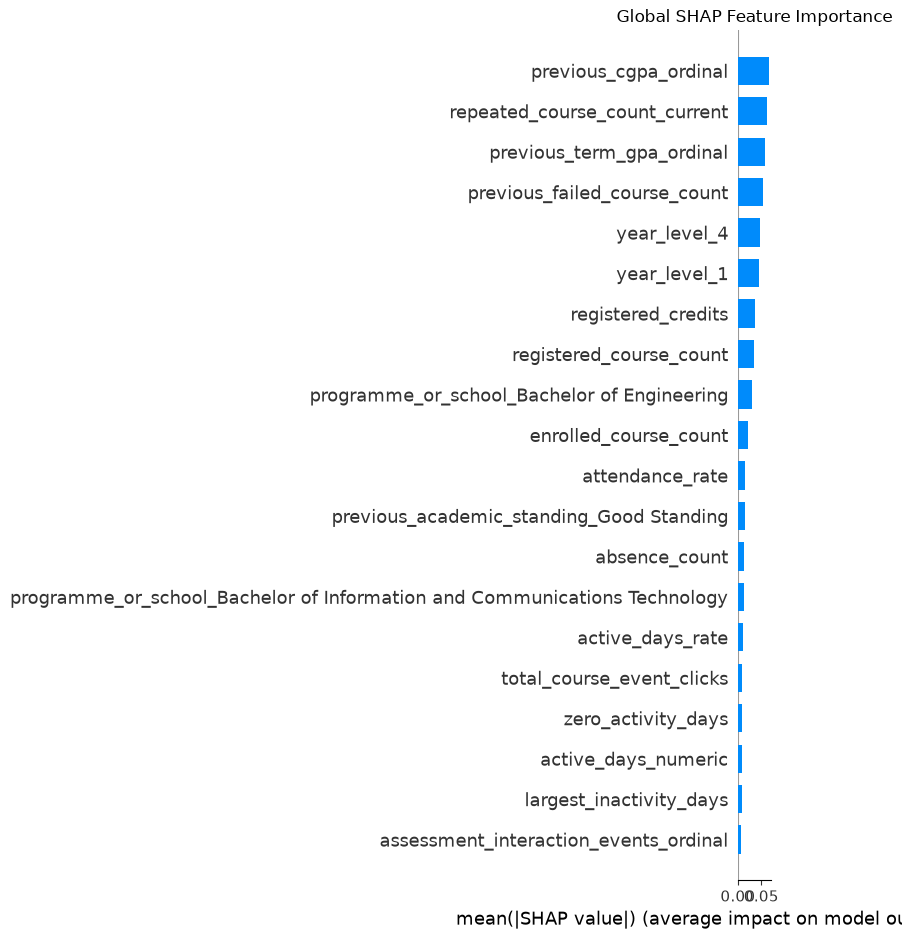

In [10]:
shap.summary_plot(
    positive_class_shap,
    X_test_prepared,
    plot_type="bar",
    max_display=20,
    show=False,
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "global_shap_bar.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


C:\Users\israa.tajaldin\AppData\Local\Temp\ipykernel_20944\3702766548.py:12: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


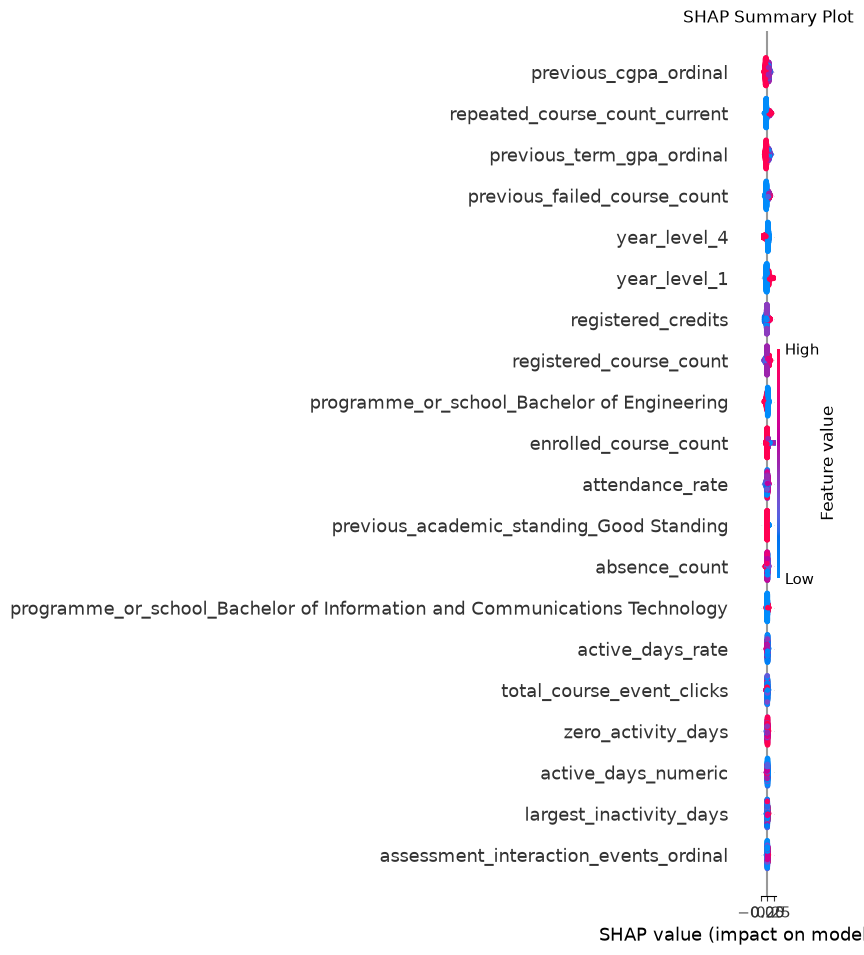

In [11]:
shap.summary_plot(
    positive_class_shap,
    X_test_prepared,
    max_display=20,
    show=False,
)

plt.title(
    "SHAP Summary Plot"
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "global_shap_summary.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 8. Define feature groups and support actions

The mapping below links model risk factors to possible support actions. It is transparent and rule based so that every recommendation can be traced to one or more SHAP identified factors.


In [12]:
INTERVENTION_LIBRARY = {
    "Tutoring and academic support": {
        "features": {
            "previous_term_gpa_ordinal",
            "previous_cgpa_ordinal",
            "previous_failed_course_count",
            "repeated_course_count_current",
            "assessment_interaction_events_ordinal",
        },
        "action": (
            "Arrange targeted tutoring, assessment support, "
            "and an academic progress review."
        ),
    },

    "Attendance support": {
        "features": {
            "attendance_rate",
            "absence_count",
        },
        "action": (
            "Review attendance barriers, agree an attendance "
            "improvement plan, and monitor attendance weekly."
        ),
    },

    "Moodle engagement support": {
        "features": {
            "course_access_rate",
            "total_course_event_clicks",
            "active_days_numeric",
            "active_days_rate",
            "zero_activity_days",
            "largest_inactivity_days",
            "learning_material_events_ordinal",
            "assessment_interaction_events_ordinal",
            "accessed_course_count",
        },
        "action": (
            "Provide an engagement plan covering course access, "
            "learning materials, assessment activity, and regular "
            "Moodle participation."
        ),
    },

    "Workload adjustment": {
        "features": {
            "registered_course_count",
            "registered_credits",
            "repeated_course_count_current",
        },
        "action": (
            "Review the student's registered workload and repeated "
            "courses with the academic adviser."
        ),
    },

    "Academic counselling": {
        "features": {
            "previous_academic_standing",
            "previous_term_gpa_ordinal",
            "previous_cgpa_ordinal",
        },
        "action": (
            "Schedule academic counselling to review progress, "
            "study barriers, and an agreed recovery plan."
        ),
    },
}

support_action_library = pd.DataFrame([
    {
        "support_area": support_area,
        "trigger_features": ", ".join(
            sorted(details["features"])
        ),
        "recommended_action": details["action"],
    }
    for support_area, details
    in INTERVENTION_LIBRARY.items()
])

display(
    support_action_library
)

support_action_library.to_csv(
    OUTPUT_DIR
    / "support_action_library.csv",
    index=False,
)


,support_area,trigger_features,recommended_action
0,Tutoring and academic support,"assessment_interaction_events_ordinal, previous_cgpa_ordinal, previous_failed_course_count, previous_term_gpa_ordinal, repeated_course_count_current","Arrange targeted tutoring, assessment support, and an academic progress review."
1,Attendance support,"absence_count, attendance_rate","Review attendance barriers, agree an attendance improvement plan, and monitor attendance weekly."
2,Moodle engagement support,"accessed_course_count, active_days_numeric, active_days_rate, assessment_interaction_events_ordinal, course_access_rate, largest_inactivity_days, learning_material_events_ordinal, total_course_eve...","Provide an engagement plan covering course access, learning materials, assessment activity, and regular Moodle participation."
3,Workload adjustment,"registered_course_count, registered_credits, repeated_course_count_current",Review the student's registered workload and repeated courses with the academic adviser.
4,Academic counselling,"previous_academic_standing, previous_cgpa_ordinal, previous_term_gpa_ordinal","Schedule academic counselling to review progress, study barriers, and an agreed recovery plan."


## 9. Helper functions for student level explanations


In [13]:
CATEGORICAL_PREFIXES = [
    "programme_or_school",
    "year_level",
    "previous_academic_standing",
]


def get_base_feature(
    prepared_feature_name,
):
    for prefix in CATEGORICAL_PREFIXES:
        if prepared_feature_name.startswith(
            prefix + "_"
        ):
            return prefix

    return prepared_feature_name


def readable_value(value):
    if pd.isna(value):
        return "Missing"

    if isinstance(
        value,
        (float, np.floating),
    ):
        return f"{value:.3f}"

    return str(value)


def risk_band(probability):
    if probability >= 0.75:
        return "High"
    if probability >= 0.50:
        return "Moderate"
    return "Low"


def student_shap_factors(
    position,
    top_n=8,
):
    shap_row = positive_class_shap[
        position
    ]

    prepared_row = (
        X_test_prepared
        .iloc[position]
    )

    raw_row = (
        X_test_raw
        .iloc[position]
    )

    factors = pd.DataFrame({
        "prepared_feature": (
            X_test_prepared.columns
        ),
        "shap_value": shap_row,
        "prepared_value": (
            prepared_row.to_numpy()
        ),
    })

    factors["base_feature"] = (
        factors["prepared_feature"]
        .map(get_base_feature)
    )

    aggregated = (
        factors
        .groupby(
            "base_feature",
            as_index=False,
        )
        .agg(
            shap_value=(
                "shap_value",
                "sum",
            )
        )
    )

    aggregated["raw_value"] = (
        aggregated["base_feature"]
        .map(
            lambda feature: (
                readable_value(
                    raw_row[feature]
                )
                if feature in raw_row.index
                else "Encoded category"
            )
        )
    )

    aggregated = (
        aggregated
        .sort_values(
            "shap_value",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    risk_increasing = (
        aggregated[
            aggregated["shap_value"] > 0
        ]
        .head(top_n)
        .copy()
    )

    return risk_increasing


def build_intervention_plan(
    position,
    top_n=8,
):
    probability = float(
        test_probabilities[position]
    )

    top_factors = student_shap_factors(
        position,
        top_n=top_n,
    )

    factor_names = set(
        top_factors["base_feature"]
    )

    recommendations = []

    for support_area, details in (
        INTERVENTION_LIBRARY.items()
    ):

        matched_features = sorted(
            factor_names
            & details["features"]
        )

        if matched_features:
            recommendations.append({
                "support_area": support_area,
                "trigger_features": ", ".join(
                    matched_features
                ),
                "recommended_action": (
                    details["action"]
                ),
            })

    represented_areas = {
        item["support_area"]
        for item in recommendations
    }

    if (
        probability >= 0.75
        or len(represented_areas) >= 3
    ):
        recommendations.append({
            "support_area": (
                "Referral and coordinated review"
            ),
            "trigger_features": (
                "High predicted risk or multiple "
                "risk domains"
            ),
            "recommended_action": (
                "Refer the case for coordinated review "
                "by the academic adviser and the relevant "
                "student support service."
            ),
        })

    case_id = (
        f"TEST_CASE_{position + 1:04d}"
    )

    return {
        "case_id": case_id,
        "test_position": position,
        "predicted_risk_probability": (
            probability
        ),
        "predicted_risk_band": (
            risk_band(probability)
        ),
        "predicted_label": int(
            probability >= 0.50
        ),
        "actual_label": int(
            y_test.iloc[position]
        ),
        "top_risk_factors": top_factors,
        "recommendations": pd.DataFrame(
            recommendations
        ),
    }


## 10. Explain one high risk student


In [14]:
highest_risk_position = int(
    np.argmax(
        test_probabilities
    )
)

example_plan = build_intervention_plan(
    highest_risk_position,
    top_n=8,
)

print("Case ID:", example_plan["case_id"])
print(
    "Predicted risk probability:",
    round(
        example_plan[
            "predicted_risk_probability"
        ],
        4,
    ),
)
print(
    "Predicted risk band:",
    example_plan[
        "predicted_risk_band"
    ],
)
print(
    "Actual label:",
    example_plan[
        "actual_label"
    ],
)

print("\nTop student level risk factors:")
display(
    example_plan[
        "top_risk_factors"
    ].round({
        "shap_value": 5,
    })
)

print("Recommended support actions:")
display(
    example_plan[
        "recommendations"
    ]
)


Case ID: TEST_CASE_0085
Predicted risk probability: 1.0
Predicted risk band: High
Actual label: 1

Top student level risk factors:


,base_feature,shap_value,raw_value
0,enrolled_course_count,0.29842,2
1,registered_course_count,0.11321,6
2,year_level,0.10714,1
3,active_days_rate,0.02261,0.000
4,absence_count,0.01866,0
5,attendance_rate,0.01849,0.000
6,largest_inactivity_days,0.01791,34
7,total_course_event_clicks,0.01373,0


Recommended support actions:


,support_area,trigger_features,recommended_action
0,Attendance support,"absence_count, attendance_rate","Review attendance barriers, agree an attendance improvement plan, and monitor attendance weekly."
1,Moodle engagement support,"active_days_rate, largest_inactivity_days, total_course_event_clicks","Provide an engagement plan covering course access, learning materials, assessment activity, and regular Moodle participation."
2,Workload adjustment,registered_course_count,Review the student's registered workload and repeated courses with the academic adviser.
3,Referral and coordinated review,High predicted risk or multiple risk domains,Refer the case for coordinated review by the academic adviser and the relevant student support service.


## 11. Display a local SHAP waterfall plot


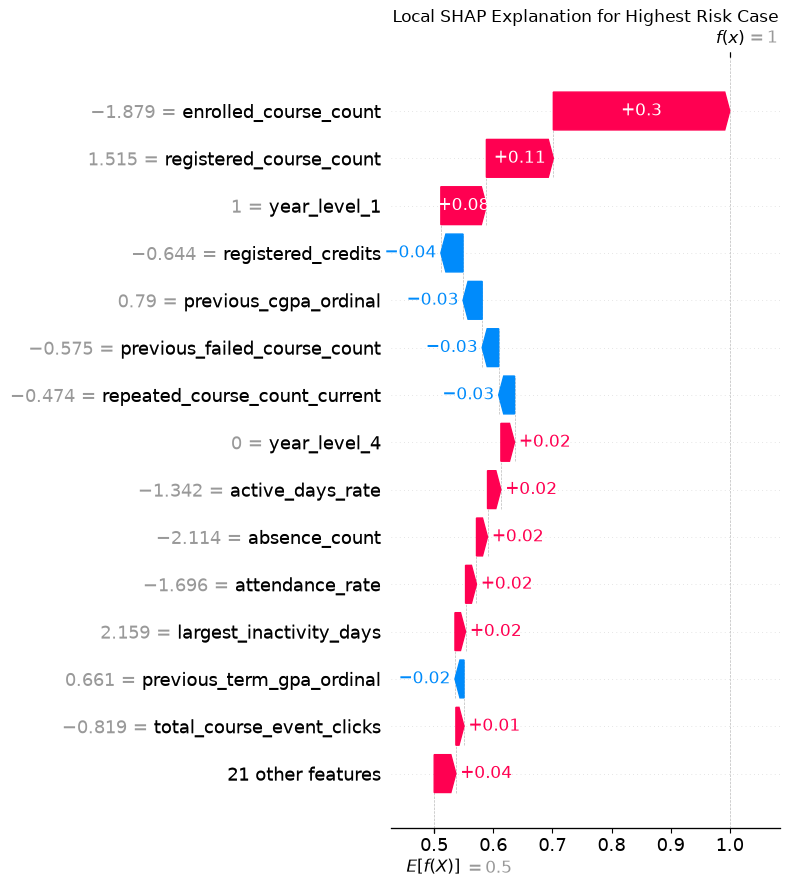

In [15]:
local_explanation = shap.Explanation(
    values=positive_class_shap[
        highest_risk_position
    ],
    base_values=(
        positive_class_base_value
    ),
    data=(
        X_test_prepared
        .iloc[
            highest_risk_position
        ]
        .to_numpy()
    ),
    feature_names=(
        X_test_prepared.columns
        .tolist()
    ),
)

shap.plots.waterfall(
    local_explanation,
    max_display=15,
    show=False,
)

plt.title(
    "Local SHAP Explanation for Highest Risk Case"
)

plt.tight_layout()
plt.savefig(
    OUTPUT_DIR
    / "highest_risk_case_waterfall.png",
    dpi=300,
    bbox_inches="tight",
)
plt.show()


## 12. Generate intervention plans for the highest risk cases


In [16]:
TOP_CASE_COUNT = 20

highest_risk_positions = (
    np.argsort(
        test_probabilities
    )[::-1][:TOP_CASE_COUNT]
)

plan_rows = []
factor_rows = []
action_rows = []

for position in highest_risk_positions:

    plan = build_intervention_plan(
        int(position),
        top_n=8,
    )

    plan_rows.append({
        "case_id": plan["case_id"],
        "test_position": (
            plan["test_position"]
        ),
        "predicted_risk_probability": (
            plan[
                "predicted_risk_probability"
            ]
        ),
        "predicted_risk_band": (
            plan["predicted_risk_band"]
        ),
        "predicted_label": (
            plan["predicted_label"]
        ),
        "actual_label": (
            plan["actual_label"]
        ),
    })

    factors = (
        plan["top_risk_factors"]
        .copy()
    )

    factors.insert(
        0,
        "case_id",
        plan["case_id"],
    )

    factor_rows.append(
        factors
    )

    actions = (
        plan["recommendations"]
        .copy()
    )

    actions.insert(
        0,
        "case_id",
        plan["case_id"],
    )

    action_rows.append(
        actions
    )


intervention_plan_summary = pd.DataFrame(
    plan_rows
)

student_factor_details = pd.concat(
    factor_rows,
    ignore_index=True,
)

student_action_details = pd.concat(
    action_rows,
    ignore_index=True,
)

display(
    intervention_plan_summary
    .head(10)
    .round({
        "predicted_risk_probability": 4,
    })
)

display(
    student_action_details
    .head(20)
)


,case_id,test_position,predicted_risk_probability,predicted_risk_band,predicted_label,actual_label
0,TEST_CASE_0085,84,1.0000,High,1,1
1,TEST_CASE_0724,723,0.9967,High,1,1
2,TEST_CASE_0561,560,0.9900,High,1,1
3,TEST_CASE_0281,280,0.9833,High,1,1
4,TEST_CASE_0507,506,0.9833,High,1,1
5,TEST_CASE_0122,121,0.9767,High,1,1
6,TEST_CASE_0341,340,0.9734,High,1,1
7,TEST_CASE_0434,433,0.9667,High,1,1
8,TEST_CASE_0524,523,0.9600,High,1,1
9,TEST_CASE_0202,201,0.9533,High,1,1


,case_id,support_area,trigger_features,recommended_action
0,TEST_CASE_0085,Attendance support,"absence_count, attendance_rate","Review attendance barriers, agree an attendance improvement plan, and monitor attendance weekly."
1,TEST_CASE_0085,Moodle engagement support,"active_days_rate, largest_inactivity_days, total_course_event_clicks","Provide an engagement plan covering course access, learning materials, assessment activity, and regular Moodle participation."
2,TEST_CASE_0085,Workload adjustment,registered_course_count,Review the student's registered workload and repeated courses with the academic adviser.
3,TEST_CASE_0085,Referral and coordinated review,High predicted risk or multiple risk domains,Refer the case for coordinated review by the academic adviser and the relevant student support service.
4,TEST_CASE_0724,Attendance support,"absence_count, attendance_rate","Review attendance barriers, agree an attendance improvement plan, and monitor attendance weekly."
5,TEST_CASE_0724,Moodle engagement support,"active_days_rate, largest_inactivity_days, zero_activity_days","Provide an engagement plan covering course access, learning materials, assessment activity, and regular Moodle participation."
6,TEST_CASE_0724,Workload adjustment,registered_course_count,Review the student's registered workload and repeated courses with the academic adviser.
7,TEST_CASE_0724,Referral and coordinated review,High predicted risk or multiple risk domains,Refer the case for coordinated review by the academic adviser and the relevant student support service.
8,TEST_CASE_0561,Tutoring and academic support,"previous_cgpa_ordinal, previous_failed_course_count, repeated_course_count_current","Arrange targeted tutoring, assessment support, and an academic progress review."
9,TEST_CASE_0561,Workload adjustment,"registered_course_count, registered_credits, repeated_course_count_current",Review the student's registered workload and repeated courses with the academic adviser.


## 13. Save SHAP and intervention outputs


In [17]:
np.save(
    OUTPUT_DIR
    / "positive_class_shap_values.npy",
    positive_class_shap,
)

intervention_plan_summary.to_csv(
    OUTPUT_DIR
    / "high_risk_case_summary.csv",
    index=False,
)

student_factor_details.to_csv(
    OUTPUT_DIR
    / "student_level_shap_factors.csv",
    index=False,
)

student_action_details.to_csv(
    OUTPUT_DIR
    / "student_intervention_actions.csv",
    index=False,
)

prediction_summary.to_csv(
    OUTPUT_DIR
    / "test_risk_predictions.csv",
    index=True,
)

joblib.dump(
    explainer,
    OUTPUT_DIR
    / "shap_explainer.joblib",
)

print("Explainability outputs saved to:")
print(OUTPUT_DIR)


Explainability outputs saved to:
c:\Users\israa.tajaldin\OneDrive - Bahrain Polytechnic\Group Group IT9099 - Israa Tajaldin - General\04_Project_Notebooks\results\explainability_interventions


## 14. Interpretation guidance

The SHAP outputs should be interpreted as explanations of the model, not as proof of causation.

- Positive SHAP values push a prediction towards the at risk class.
- Negative SHAP values push a prediction towards the not at risk class.
- Global SHAP importance shows which features the model relies on most across students.
- Local SHAP values show why the model assigned a particular risk score to one case.
- The intervention module links identified risk factors to transparent rule based support actions.
- Recommendations must be reviewed by academic staff before implementation.
- Programme, year level, and other contextual features should not independently trigger a negative intervention decision.


## Notebook 04 Summary

This notebook implemented the first version of Objective 2. It generated global and student level SHAP explanations for the selected baseline model and translated important student level risk factors into transparent support recommendations.

The intervention library covers tutoring and academic support, counselling, attendance support, Moodle engagement support, workload review, and coordinated referral. Anonymised intervention plans were generated for the highest risk test cases and saved for review.

The next stage is to validate the relevance and feasibility of the recommended interventions and later connect mutable features to the dynamic reassessment module.
